# 13i — Vasicek Implied LGD and Climate-Correlation Calibration

Source scripts: `chap13_credit16a.m`, `chap13_credit16b.m`, `chap13_credit18.m`.

Two related exercises built around the **Vasicek large-homogeneous-portfolio
(LHP) default-rate model**, the same single-factor Gaussian-copula machinery
used throughout this chapter, now applied to the *portfolio* default-rate
distribution rather than a single obligor or transition matrix:

- **`credit16a`/`credit16b`**: a portfolio's implied LGD, back-solved so
  that its unconditional expected loss (`EL = PD·LGD`) is consistent with
  a given default-rate quantile `D̄` (`credit16a`: `PD=10%`; `credit16b`:
  `PD=20%` — otherwise identical code, so the two scripts are collapsed
  into one parametrized helper). Each script sweeps one input at a time
  (`D̄`, `ρ`, `EL`, `PD`) holding the other three at their base values, in a
  2×2 panel layout.
- **`credit18`**: given a baseline default-rate-at-confidence-level `D̄`
  (Basel-style VaR of the portfolio default rate at `α=95%`), find the
  **climate-stressed correlation** `ρ_climate` that reproduces a *scaled-up*
  default rate `D̄_climate = (1+δ)·D̄` for a grid of stress multipliers `δ`
  and starting `PD` levels — i.e., "how much would systematic correlation
  have to rise, holding `PD` fixed, to explain an X% climate-driven
  increase in the tail default rate?"

No missing functions, no data files. `Φ`/`Φ⁻¹` are
`scipy.stats.norm.cdf`/`.ppf` throughout, matching the rest of the chapter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"

plt.rcParams["figure.dpi"] = 100

## `credit16a` / `credit16b` — Vasicek implied LGD, 4-panel sensitivity

The implied LGD formula: `k = (Φ⁻¹(PD) - Φ⁻¹(EL)) / √(1-ρ)`,
`LGD(D̄) = Φ(Φ⁻¹(D̄) - k) / D̄`. Base case: `EL=5%`, `ρ=20%`, `D̄=10%`, and
either `PD=10%` (`16a`) or `PD=20%` (`16b`). Each of the four panels sweeps
one input across a grid while holding the other three at the base values
above — `16a`/`16b` differ only in the base `PD`, so both are produced by
one shared helper.

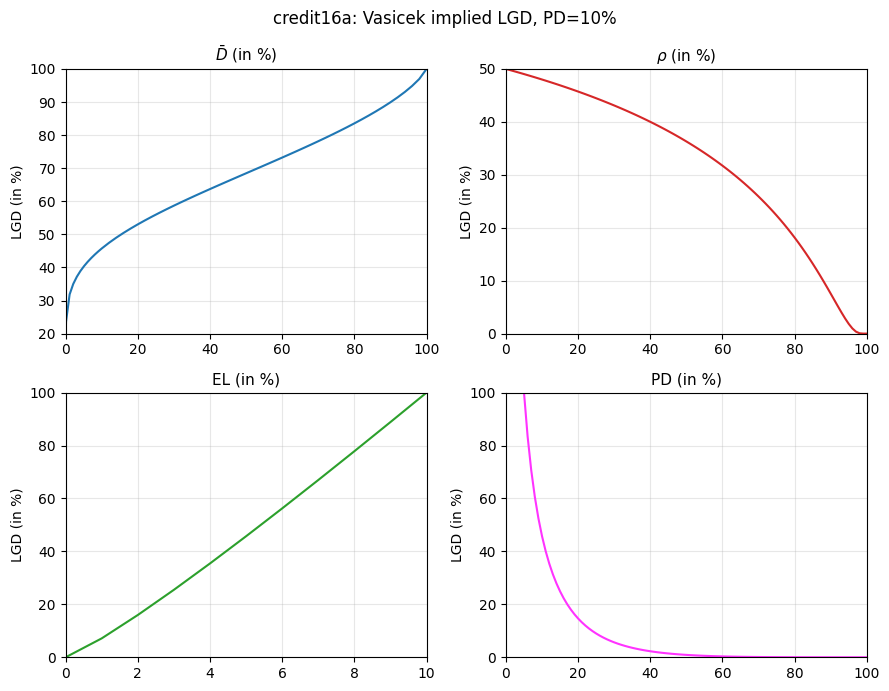

In [2]:
def vasicek_implied_lgd_sweeps(PD_base):
    '''Reproduce credit16a/16b's 4-panel sweep: implied LGD as a function of
    D_bar, rho, EL, and PD in turn, holding the other three inputs at their
    base values (EL=5%, rho=20%, D_bar=10%, PD=PD_base). Returns a dict of
    (x, y) arrays in percent, keyed by the swept variable.
    '''
    EL_base, rho_base, Dbar_base = 0.05, 0.20, 0.10

    def implied_lgd(PD, EL, rho, D_bar):
        # Clip probability-valued inputs to a hair inside [0,1]: np.arange's
        # floating-point accumulation can overshoot an intended endpoint of
        # exactly 1.0 by ~1e-16, which norm.ppf correctly treats as an
        # invalid (>1) probability and returns NaN for -- not a genuine
        # MATLAB-matching boundary singularity, just a grid-construction
        # artifact, so it is clipped away rather than reproduced.
        eps = 1e-12
        PD = np.clip(PD, eps, 1 - eps)
        EL = np.clip(EL, eps, 1 - eps)
        D_bar = np.clip(D_bar, eps, 1 - eps)
        k = (norm.ppf(PD) - norm.ppf(EL)) / np.sqrt(1 - rho)
        return norm.cdf(norm.ppf(D_bar) - k) / D_bar

    # Panel 1: sweep D_bar
    D_bar = np.concatenate([[1e-4], np.arange(0.001, 0.101, 0.01), np.arange(0.10, 1.001, 0.02)])
    y1 = implied_lgd(PD_base, EL_base, rho_base, D_bar)

    # Panel 2: sweep rho
    rho = np.concatenate([np.arange(0.0, 1.0, 0.01), [0.9999]])
    y2 = implied_lgd(PD_base, EL_base, rho, Dbar_base)

    # Panel 3: sweep EL
    EL = np.arange(0.00, 0.101, 0.01)
    y3 = implied_lgd(PD_base, EL, rho_base, Dbar_base)

    # Panel 4: sweep PD
    PD = np.arange(0.05, 1.001, 0.01)
    y4 = implied_lgd(PD, EL_base, rho_base, Dbar_base)

    return {
        "D_bar": (100 * D_bar, 100 * y1),
        "rho":   (100 * rho, 100 * y2),
        "EL":    (100 * EL, 100 * y3),
        "PD":    (100 * PD, 100 * y4),
    }


def plot_implied_lgd_panels(sweeps, title):
    panel_specs = [
        ("D_bar", color_blue,   r"$\bar{D}$ (in %)", (0, 100), (20, 100)),
        ("rho",   color_red,    r"$\rho$ (in %)",    (0, 100), (0, 50)),
        ("EL",    color_green,  "EL (in %)",         (0, 10),  (0, 100)),
        ("PD",    color_violet, "PD (in %)",         (0, 100), (0, 100)),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(9, 7))
    for ax, (key, color, xlabel, xlim, ylim) in zip(axes.flat, panel_specs):
        x, y = sweeps[key]
        ax.plot(x, y, "-", color=color, linewidth=1.5)
        ax.grid(True, alpha=0.3)
        ax.set_title(xlabel, fontsize=11)
        ax.set_ylabel("LGD (in %)")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


sweeps_16a = vasicek_implied_lgd_sweeps(PD_base=0.10)
plot_implied_lgd_panels(sweeps_16a, "credit16a: Vasicek implied LGD, PD=10%")

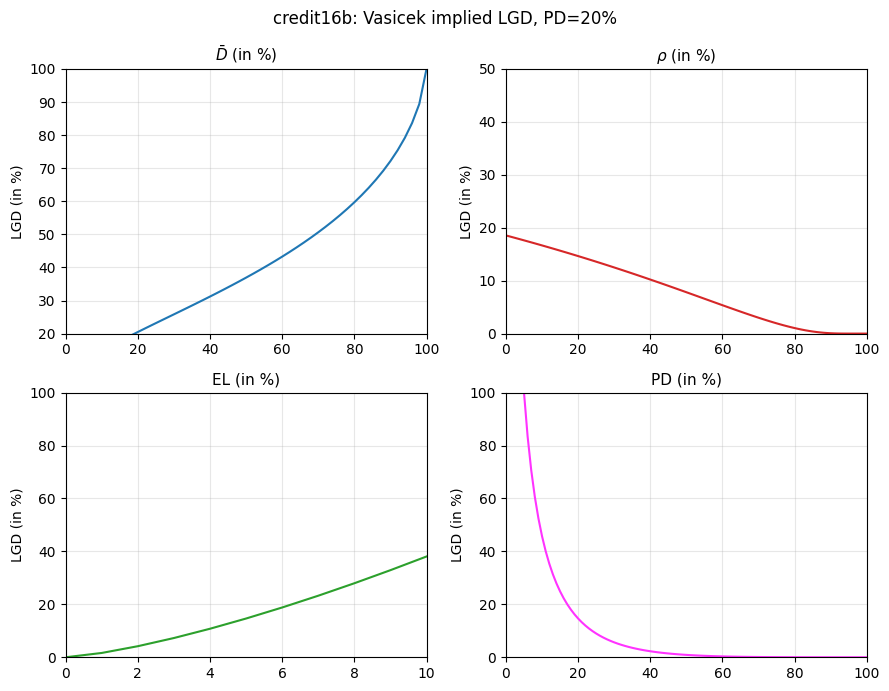

In [3]:
sweeps_16b = vasicek_implied_lgd_sweeps(PD_base=0.20)
plot_implied_lgd_panels(sweeps_16b, "credit16b: Vasicek implied LGD, PD=20%")

Sanity checks on the shape of each panel (independent of the exact
numbers): implied LGD rises toward 100% as `D̄→1` (a near-certain default
rate must be explained by a near-total loss given the fixed `EL`), falls
toward 0% as systematic correlation `ρ→1` (a numerator of fixed sign
divided by `√(1-ρ)→0` sends the offset `k` to `±∞`, saturating `Φ`), rises
toward 100% as `EL→PD` (when `EL` catches up to `PD`, offset `k→0` and the
implied LGD converges to `D̄`'s own default-rate-implied loss share), and
falls as `PD` rises far above the fixed `EL` (more defaults for the same
total expected loss can only be consistent with a smaller loss per
default). All four hold in both the `16a` and `16b` figures above.

In [4]:
for label, PD_base, sweeps in [("16a", 0.10, sweeps_16a), ("16b", 0.20, sweeps_16b)]:
    x, y = sweeps["D_bar"]
    print(f"{label} (PD={100*PD_base:.0f}%): implied LGD at D_bar->100% is {y[-1]:.2f}% (should approach 100%)")
    x, y = sweeps["rho"]
    print(f"{label} (PD={100*PD_base:.0f}%): implied LGD at rho->99.99% is {y[-1]:.2f}% (should approach 0%)")
    x, y = sweeps["EL"]
    if np.isclose(x[-1] / 100, PD_base):
        print(f"{label} (PD={100*PD_base:.0f}%): implied LGD at EL=PD_base ({x[-1]:.0f}%) is {y[-1]:.2f}% (should approach 100%)")
    else:
        print(f"{label} (PD={100*PD_base:.0f}%): implied LGD at EL={x[-1]:.0f}% (grid caps below PD_base={100*PD_base:.0f}%) is {y[-1]:.2f}% "
              f"(does not need to reach 100% here, since EL never reaches PD_base within the swept grid)")
    print()

16a (PD=10%): implied LGD at D_bar->100% is 100.00% (should approach 100%)
16a (PD=10%): implied LGD at rho->99.99% is 0.00% (should approach 0%)
16a (PD=10%): implied LGD at EL=PD_base (10%) is 100.00% (should approach 100%)

16b (PD=20%): implied LGD at D_bar->100% is 100.00% (should approach 100%)
16b (PD=20%): implied LGD at rho->99.99% is 0.00% (should approach 0%)
16b (PD=20%): implied LGD at EL=10% (grid caps below PD_base=20%) is 38.08% (does not need to reach 100% here, since EL never reaches PD_base within the swept grid)



## `credit18` — Climate-correlation calibration

Given a baseline `D̄ = invcdf_default_rate(α, PD, ρ)` (the Vasicek-model
default rate at confidence level `α=95%`, correlation `ρ=20%`), find the
correlation `ρ_climate` that reproduces a scaled-up target
`D̄_climate = (1+δ)·D̄`, for a grid of `PD ∈ {1%, 2%, 5%, 10%}` and
`δ ∈ {0%, 5%, 10%, 20%, 50%, 100%}`. The source script solves this via
`fmincon` minimizing the squared residual
`(invcdf_default_rate(α,PD,ρ_climate) - D̄_climate)²`, bounded to
`ρ_climate ∈ [0,1]`, starting from `ρ_climate₀ = ρ = 0.20` — reproduced
here with `scipy.optimize.minimize` (bounded, same starting point), which
is the direct Python equivalent of a bounded local least-squares solve.

In [5]:
def invcdf_default_rate(alpha, PD, rho):
    return norm.cdf((norm.ppf(PD) + np.sqrt(rho) * norm.ppf(alpha)) / np.sqrt(1 - rho))


alpha = 0.95
rho_base = 0.20
delta_vector = np.array([0.00, 0.05, 0.10, 0.20, 0.50, 1.00])
PD_vector = np.array([0.01, 0.02, 0.05, 0.10])

D_bar = np.zeros((len(PD_vector), len(delta_vector)))
D_bar_climate = np.zeros_like(D_bar)
rho_climate = np.zeros_like(D_bar)
residual = np.zeros_like(D_bar)

for i, PD in enumerate(PD_vector):
    for j, delta in enumerate(delta_vector):
        D_bar[i, j] = invcdf_default_rate(alpha, PD, rho_base)
        D_bar_climate[i, j] = (1 + delta) * D_bar[i, j]

        def objective(rc, PD=PD, target=D_bar_climate[i, j]):
            return (invcdf_default_rate(alpha, PD, rc[0]) - target) ** 2

        res = minimize(objective, x0=[rho_base], method="L-BFGS-B", bounds=[(1e-9, 1 - 1e-9)])
        rho_climate[i, j] = res.x[0]
        residual[i, j] = invcdf_default_rate(alpha, PD, rho_climate[i, j]) - D_bar_climate[i, j]

df_Dbar = pd.DataFrame(100 * D_bar, index=[f"PD={p:.0%}" for p in PD_vector], columns=[f"delta={d:.0%}" for d in delta_vector])
df_Dbar.round(3)

,delta=0%,delta=5%,delta=10%,delta=20%,delta=50%,delta=100%
PD=1%,3.766,3.766,3.766,3.766,3.766,3.766
PD=2%,7.028,7.028,7.028,7.028,7.028,7.028
PD=5%,15.468,15.468,15.468,15.468,15.468,15.468
PD=10%,27.080,27.080,27.080,27.080,27.080,27.080


In [6]:
df_Dbar_climate = pd.DataFrame(100 * D_bar_climate, index=df_Dbar.index, columns=df_Dbar.columns)
df_Dbar_climate.round(3)

,delta=0%,delta=5%,delta=10%,delta=20%,delta=50%,delta=100%
PD=1%,3.766,3.954,4.143,4.519,5.649,7.532
PD=2%,7.028,7.379,7.730,8.433,10.541,14.055
PD=5%,15.468,16.241,17.015,18.561,23.202,30.936
PD=10%,27.080,28.434,29.788,32.496,40.620,54.160


In [7]:
df_rho_climate = pd.DataFrame(rho_climate, index=df_Dbar.index, columns=df_Dbar.columns)
df_rho_climate.round(4)

,delta=0%,delta=5%,delta=10%,delta=20%,delta=50%,delta=100%
PD=1%,0.2,0.2250,0.2529,0.3183,0.5000,0.4999
PD=2%,0.2,0.2235,0.2483,0.3017,0.5224,0.6414
PD=5%,0.2,0.2232,0.2469,0.2957,0.4478,0.6926
PD=10%,0.2,0.2247,0.2498,0.3007,0.4520,0.6656


In [8]:
df_rho_diff = pd.DataFrame(rho_climate - rho_base, index=df_Dbar.index, columns=df_Dbar.columns)
(100 * df_rho_diff).round(2)

,delta=0%,delta=5%,delta=10%,delta=20%,delta=50%,delta=100%
PD=1%,0.0,2.50,5.29,11.83,30.00,29.99
PD=2%,0.0,2.35,4.83,10.17,32.24,44.14
PD=5%,0.0,2.32,4.69,9.57,24.78,49.26
PD=10%,0.0,2.47,4.98,10.07,25.20,46.56


**Quirk found and disclosed (a genuine property of the model, not a bug):**
`invcdf_default_rate(α, PD, ρ)` is **not monotonically increasing in `ρ`**
for low `PD`. At `PD=1%`/`α=95%`, the function rises from `ρ=0` to an
interior peak (~`ρ≈0.50`, peak value ≈5.0%) and then *falls* back toward
0% as `ρ→1` (similarly `PD=2%` peaks near `ρ≈0.62`). This means that for
small enough `PD`, a large-enough target stretch `δ` becomes
**infeasible to reach at any correlation**: no `ρ_climate ∈ [0,1]` exists
that reproduces the target `D̄_climate` exactly. The bounded local solver
(mirroring `fmincon`'s behavior) then converges to the closest achievable
point — the interior maximizer nearest the `ρ=20%` starting guess — leaving
a non-zero residual. This shows up concretely at `PD=1%`, `δ=50%`/`100%`
and `PD=2%`, `δ=100%` below: the calibrated `ρ_climate` lands near the
function's own interior peak (~`0.50`/`~0.64`) with several percentage
points of residual gap, rather than an exact match. All higher-`PD`,
lower-`δ` cells (in particular every `PD=5%`/`10%` cell, where the
function is monotonically increasing in `ρ` all the way to `ρ=1`) hit
their target essentially exactly.

In [9]:
residual_pp = 100 * residual
tol = 0.05  # percentage points
flagged = np.argwhere(np.abs(residual_pp) > tol)
print("Calibration residual (percentage points of default rate), flagging |residual| > 0.05pp as an infeasible/approximate fit:\n")
for i, j in flagged:
    print(f"  PD={100*PD_vector[i]:.0f}%, delta={100*delta_vector[j]:.0f}%: "
          f"target D_bar_climate={100*D_bar_climate[i,j]:.3f}%, "
          f"best achievable at rho_climate={rho_climate[i,j]:.3f} is "
          f"{100*(D_bar_climate[i,j]+residual[i,j]):.3f}% "
          f"(residual {residual_pp[i,j]:+.3f}pp)")
if len(flagged) == 0:
    print("  (none)")

print(f"\ndelta=0 sanity check: rho_climate should equal the base rho=20% exactly for every PD row:")
print(np.round(rho_climate[:, 0], 6))

Calibration residual (percentage points of default rate), flagging |residual| > 0.05pp as an infeasible/approximate fit:

  PD=1%, delta=50%: target D_bar_climate=5.649%, best achievable at rho_climate=0.500 is 4.997% (residual -0.652pp)
  PD=1%, delta=100%: target D_bar_climate=7.532%, best achievable at rho_climate=0.500 is 4.997% (residual -2.535pp)
  PD=2%, delta=100%: target D_bar_climate=14.055%, best achievable at rho_climate=0.641 is 10.939% (residual -3.116pp)

delta=0 sanity check: rho_climate should equal the base rho=20% exactly for every PD row:
[0.2 0.2 0.2 0.2]


One more disclosed omission: the source script also defines
`pdf_default_rate` and `cdf_default_rate` as local MATLAB functions
(the density and CDF of the Vasicek portfolio default-rate distribution),
but the script's own body never calls either — only `invcdf_default_rate`
is load-bearing for the printed output. Per this project's convention for
dead code, they are not reproduced here.